In [3]:
import os
import numpy as np
import imageio.v2 as imageio

folder = "UF181992"

files = sorted([f for f in os.listdir(folder) if f.endswith(".tif")])

volume = np.stack([imageio.imread(os.path.join(folder, f)) for f in files])

print(volume.shape)  # (slices, height, width)

(2700, 1032, 1140)


In [4]:
# Process dataset: UF181992 is already a skeleton stack; Zstack contains full body
volume = volume.astype(np.float32)

if folder == "UF181992":
    # Assume non-zero voxels are the skeleton already — show as a 3D structure
    skel = volume > 0
    points = np.argwhere(skel)
    print("UF181992 skeleton points:", points.shape)

    import pyvista as pv
    if len(points) > 0:
        cloud = pv.PolyData(points)
        # Use small spheres (glyphs) to give a volumetric 3D appearance
        sphere = pv.Sphere(radius=0.6)
        glyph = cloud.glyph(geom=sphere, factor=1.0)
        p = pv.Plotter(window_size=(1000,700))
        p.add_mesh(glyph, color="ivory", smooth_shading=True)
        p.set_background("black")
        p.add_text("UF181992: 3D Skeleton (glyphs)", font_size=14)
        p.show()
    else:
        print("No skeleton points found in UF181992")
else:
    # For non-skeleton stacks (e.g. Zstack) keep the previous normalize + threshold behavior
    volume = (volume - volume.min()) / (volume.max() - volume.min())
    # threshold (you may need to tweak this!)
    bone = volume > 0.6


In [5]:
# Additional morphology was previously applied here; processing is handled in the UF/Zstack cells now
pass

In [6]:
# Skeletonization moved into dataset-specific cells; no-op placeholder
pass

/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/755488850.py:18: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bone_mask = remove_small_objects(bone_mask, min_size=50)


Bone voxels: 6452700
Skeleton centerline points: 585622


/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/755488850.py:30: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  cloud = pv.PolyData(skeleton_points)
/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/755488850.py:31: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  cloud.plot(point_size=5, render_points_as_spheres=True, window_size=(800, 600))


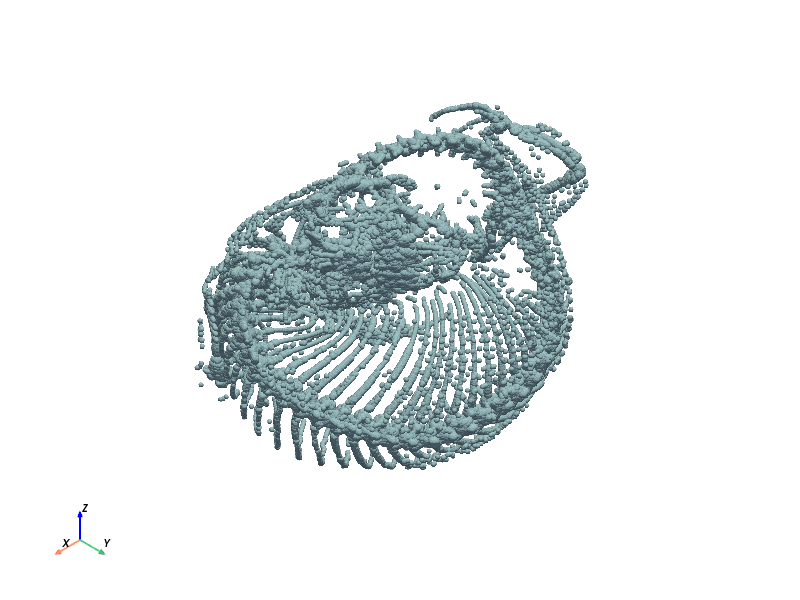

In [17]:
import pyvista as pv
from scipy.ndimage import gaussian_filter, binary_erosion
from skimage.morphology import remove_small_objects, skeletonize

# Smooth the data first
volume_smooth = gaussian_filter(volume.astype(np.float32), sigma=1)

# Use VERY HIGH density threshold to isolate ONLY bones (98th percentile)
bone_threshold = np.percentile(volume_smooth, 98)
bone_mask = volume_smooth > bone_threshold

# Remove outer skin layer with VERY aggressive erosion
body = volume_smooth > np.percentile(volume_smooth, 20)
skin_removed = binary_erosion(body, iterations=20)

# Keep only bones inside the animal
bone_mask = bone_mask & skin_removed
bone_mask = remove_small_objects(bone_mask, min_size=50)

print(f"Bone voxels: {np.sum(bone_mask)}")

# Extract 3D skeleton (centerline, not surface)
skeleton = skeletonize(bone_mask)

# Visualize
skeleton_points = np.argwhere(skeleton)
print(f"Skeleton centerline points: {len(skeleton_points)}")

if len(skeleton_points) > 0:
    cloud = pv.PolyData(skeleton_points)
    cloud.plot(point_size=5, render_points_as_spheres=True, window_size=(800, 600))
else:
    print("No skeleton found")

Original shape: (1841, 1290, 1629)


/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/657507057.py:36: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=500)


Skeleton points: (4294148, 3)


/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/657507057.py:54: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  cloud = pv.PolyData(points)
/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/657507057.py:55: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  cloud.plot(point_size=2, render_points_as_spheres=True)


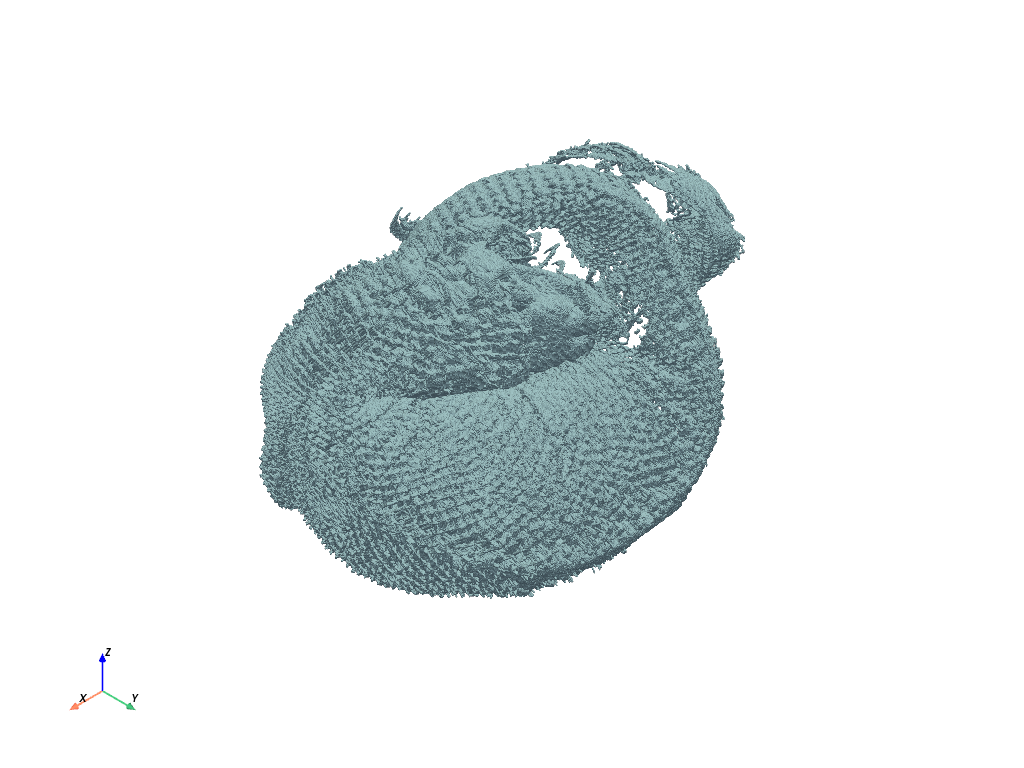

In [7]:
import os
import numpy as np
import imageio.v2 as imageio
import pyvista as pv

from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize, remove_small_objects
from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage import measure

# ----------------------------
# 1. Load CT stack
# ----------------------------
folder = "Zstack"
files = sorted([f for f in os.listdir(folder) if f.endswith(".tif")])

volume = np.stack([
    imageio.imread(os.path.join(folder, f))
    for f in files
])

print("Original shape:", volume.shape)

# ----------------------------
# 2. Downsample (optional)
# ----------------------------
volume = volume[::2, ::2, ::2]

# ----------------------------
# 3. Denoise (VERY important for CT)
# ----------------------------
volume_smooth = gaussian_filter(volume, sigma=1)

# Bone (dense) threshold — keep this logic as requested
thresh = np.percentile(volume, 90)
binary = volume_smooth > thresh

binary = remove_small_objects(binary, min_size=500)
binary = binary_fill_holes(binary)

# Extract 2D skeleton per-slice (keeps working bone extraction)
skeleton = np.zeros_like(binary, dtype=bool)
for z in range(binary.shape[0]):
    skeleton[z] = skeletonize(binary[z])

# ----------------------------
# 7. Extract skeleton points (for bone visualization)
# ----------------------------
points = np.argwhere(skeleton)
print("Skeleton points:", points.shape)

# ----------------------------
# 8. Smooth body visualization (surface) for demo — create an isosurface and smooth it
# ----------------------------
# Create a body mask (looser threshold to capture skin/body)
body_mask = volume_smooth > np.percentile(volume_smooth, 20)
body_mask = binary_fill_holes(body_mask)

# Use marching cubes to create a surface mesh from the body mask
verts, faces, normals, values = measure.marching_cubes(body_mask.astype(np.uint8), level=0)
# faces are (n, 3) triangles — pyvista accepts this directly
mesh = pv.PolyData(verts, faces)
# Apply Laplacian smoothing to make the surface nicer for demo
try:
    mesh_smooth = mesh.smooth(n_iter=30)
except Exception:
    mesh_smooth = mesh

# Plot both body mesh and skeleton points together for a clear demo
p = pv.Plotter(window_size=(1100,800))
p.add_mesh(mesh_smooth, color="lightgray", opacity=0.8, smooth_shading=True)
if len(points) > 0:
    cloud = pv.PolyData(points)
    glyph = cloud.glyph(geom=pv.Sphere(radius=0.5), factor=1.0)
    p.add_mesh(glyph, color="white")
p.set_background("black")
p.add_text("Zstack: Smoothed body + extracted bones", font_size=14)
p.show()

/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/3442783150.py:32: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bone_mask = remove_small_objects(bone_mask, min_size=50)


Bone density threshold: 23003.0
Bone voxels: 6449124
Skeleton centerline points: 585491


/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/3442783150.py:49: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  cloud = pv.PolyData(skeleton_points)
/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_18470/3442783150.py:50: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  cloud.plot(point_size=5, render_points_as_spheres=True, window_size=(800, 600))


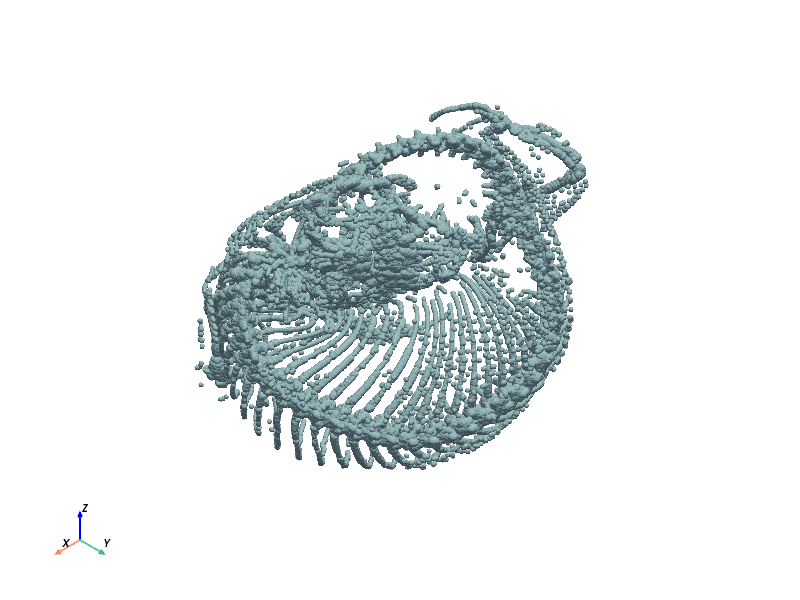

In [18]:
import numpy as np
import pyvista as pv
from scipy.ndimage import gaussian_filter, binary_erosion
from skimage.morphology import remove_small_objects, skeletonize

# ----------------------------
# Smooth volume
# ----------------------------
volume_smooth = gaussian_filter(volume, sigma=1)

# VERY STRICT bone density threshold (only densest material)
bone_threshold = np.percentile(volume_smooth, 98)
bone_mask = volume_smooth > bone_threshold

# Remove outer skin layer with aggressive erosion
body = volume_smooth > np.percentile(volume_smooth, 20)
skin_removed = binary_erosion(body, iterations=20)

bone_mask = bone_mask & skin_removed
bone_mask = remove_small_objects(bone_mask, min_size=50)

print(f"Bone density threshold: {bone_threshold:.1f}")
print(f"Bone voxels: {np.sum(bone_mask)}")

# Extract 3D skeleton (centerline)
skeleton = skeletonize(bone_mask)
skeleton_points = np.argwhere(skeleton)
print(f"Skeleton centerline points: {len(skeleton_points)}")

# Render skeleton with glyphs for a thicker 3D look
if len(skeleton_points) > 0:
    cloud = pv.PolyData(skeleton_points)
    glyph = cloud.glyph(geom=pv.Sphere(radius=0.6), factor=1.0)
    p = pv.Plotter(window_size=(900,700))
    p.add_mesh(glyph, color="white", smooth_shading=True)
    p.set_background("black")
    p.add_text("Strict bones: centerline (glyphs)", font_size=12)
    p.show()
else:
    print("No skeleton points found - threshold may be too strict")